In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from preprocess_Bin import preprocess_data


# ============================================================
# 仅列出目录下所有 bin 文件（不读取数据）
# ============================================================
def list_bin_files(folder_path):
    return sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".bin")])


# ============================================================
# 读取单个文件（准确版）
# ============================================================
def read_one_bin(folder_path, filename):
    file_path = os.path.join(folder_path, filename)

    with open(file_path, 'rb') as f:
        header = np.fromfile(f, dtype=np.float32, count=20)

        N_diff = int(header[8])     # channels
        n = int(header[7])          # frames
        fs = float(header[9])       # sampling freq

        expected = N_diff * n
        data = np.fromfile(f, dtype=np.float32, count=expected)

    data = data.reshape((N_diff, n))        # shape (channels, frames)
    return data, fs

解析文件名（通道 + 时间）

In [8]:
import os
import re
import datetime as dt

def parse_bin_filename(filename):
    """
    解析 bin 文件名，提取通道号和时间
    兼容两种格式：
    1) ch1#2025-11-23-20-58-32.bin
    2) 2026-03-01_14-41-58.bin
    """
    name = os.path.basename(filename)

    # 格式1：ch1#2025-11-23-20-58-32.bin
    pattern1 = r"ch(\d+)#(\d{4}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})\.bin"
    m = re.match(pattern1, name)
    if m:
        ch = int(m.group(1))
        t = dt.datetime.strptime(m.group(2), "%Y-%m-%d-%H-%M-%S")
        return ch, t
    
    # 格式3：ch1_2026-05-20-22-50-54_其他内容.bin （新增）
    pattern3 = r"ch(\d+)_(\d{4}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})"  # 不要求结尾，只要开头匹配即可
    m = re.match(pattern3, name)
    if m:
        ch = int(m.group(1))
        t = dt.datetime.strptime(m.group(2), "%Y-%m-%d-%H-%M-%S")
        return ch, t
    
    # 格式2：2026-03-01_14-41-58.bin
    pattern2 = r"(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})\.bin"
    m = re.match(pattern2, name)
    if m:
        ch = None
        t = dt.datetime.strptime(m.group(1) + "-" + m.group(2), "%Y-%m-%d-%H-%M-%S")
        return ch, t

    raise ValueError(f"文件名格式不符合约定: {filename}")


def parse_file_range(file_range):
    """
    解析 file_range 字符串
    返回: channel, start_time, end_time
    兼容两种范围格式：
    1) ch1#2025-11-23-20-58-32 : ch1#2025-11-23-20-59-32
    2) 2026-03-01_14-41-58 : 2026-03-01_14-45-58
    """
    start_str, end_str = [s.strip() for s in file_range.split(":")]

    ch1, t_start = parse_bin_filename(start_str + ".bin")
    ch2, t_end   = parse_bin_filename(end_str + ".bin")

    # 如果两端都带通道号，则要求一致
    if ch1 is not None and ch2 is not None and ch1 != ch2:
        raise ValueError("起止文件通道号不一致，当前版本不支持跨通道范围")

    if t_start > t_end:
        raise ValueError("起始时间晚于结束时间")

    # 返回非 None 的通道号；如果都没有，则返回 None
    ch_target = ch1 if ch1 is not None else ch2
    return ch_target, t_start, t_end


def select_bin_files(folder_path, file_range):
    """
    根据 file_range 筛选 bin 文件（不读取数据）
    """
    ch_target, t_start, t_end = parse_file_range(file_range)

    files = list_bin_files(folder_path)
    selected = []

    for f in files:
        try:
            ch, t = parse_bin_filename(f)
        except ValueError:
            continue

        # 如果文件本身没有通道号，则只按时间筛选
        if ch_target is None:
            if t_start <= t <= t_end:
                selected.append(f)
        else:
            if ch == ch_target and t_start <= t <= t_end:
                selected.append(f)

    return selected

选择文件路径及范围

In [ ]:
folder = r"K:\回采文件与代码"
file_range = "ch1_2026-07-05-10-28-40_2_120832_149_2000: ch1_2026-07-05-10-28-40_2_120832_149_2000"
files_selected = select_bin_files(folder, file_range)
print("选中的文件：")

for f in files_selected:
    try:
        data, fs = read_one_bin(folder, f)
        print(f"{f}    通道数：{data.shape[0]}")

    except Exception as e:
        print(f"{f}    读取失败：{e}")

选中的文件：
ch1_2026-07-05-10-28-40_2_120832_149_2000.bin
ch1_2026-07-05-10-28-40_2_120832_149_2000.bin 通道数: 149


绘制整体瀑布图


=== 处理文件：ch1_2026-07-05-10-28-40_2_120832_149_2000.bin ===


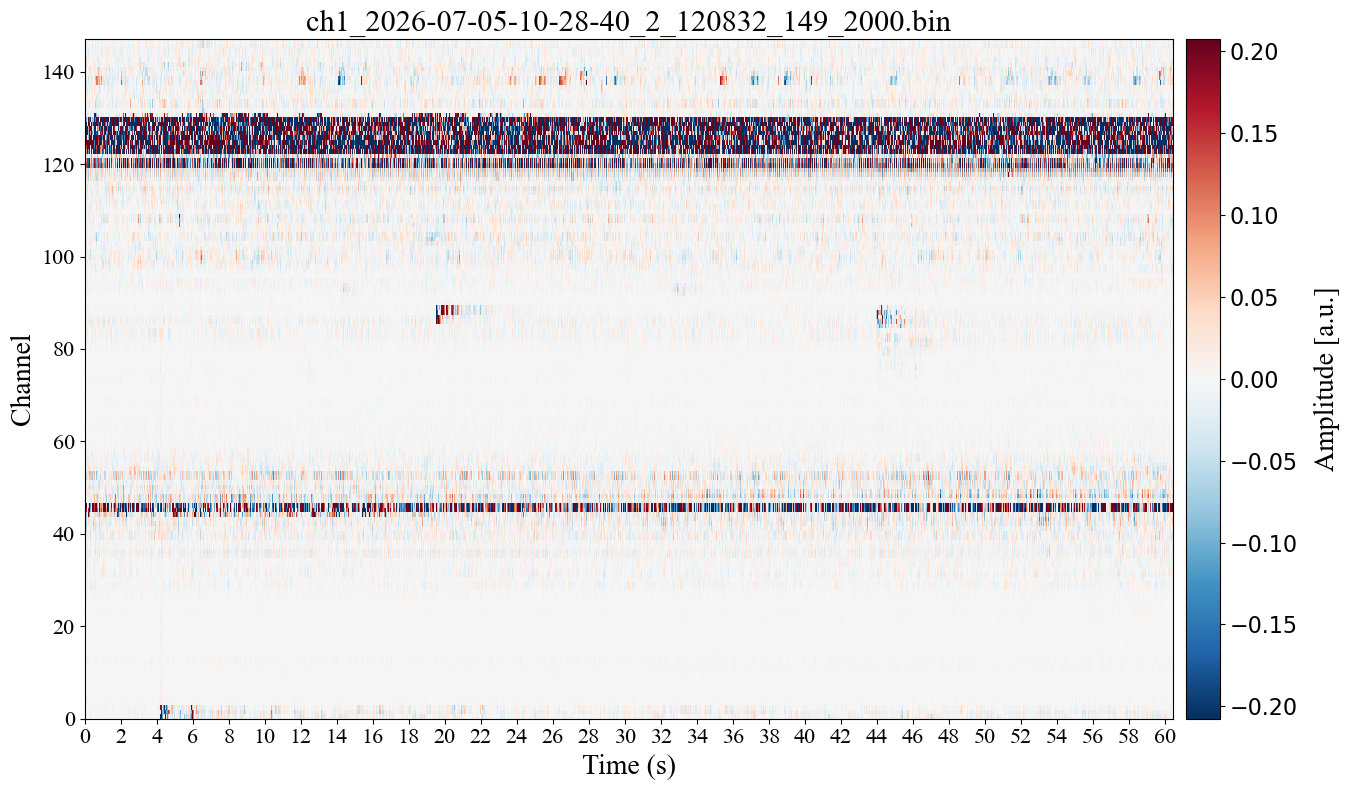

In [ ]:
# 主程序：逐文件读取 → 预处理 → 瀑布图

# 只返回文件名，不读取数据
files = files_selected

for fname in files:

    print(f"\n=== 处理文件：{fname} ===")

    # 读取单个文件
    data, fs = read_one_bin(folder, fname)

    # 预处理
    data_p = preprocess_data(
        data,
        fs=fs,
        channel_start=0,
        channel_end=data.shape[0] - 1,
        freqmin=5, freqmax=50, bandpass_corners=4,
        remove_trend=True,
        remove_mean=True,
        apply_common_mode=False,
        downsample_factor=1,
        zerophase=False
    )

    # 预处理后方向仍为 (channels, frames)
    n_channels, n_frames = data_p.shape

    # 正确的时间轴
    time_seconds = np.arange(n_frames) / fs
    t_end = time_seconds[-1]

    # 瀑布图绘图
    fig, ax = plt.subplots(figsize=(14, 8))

    vmax = np.percentile(data_p, 98)
    vmin = np.percentile(data_p, 2)

    im = ax.imshow(
        data_p,          # (channels, frames) 正常方向
        aspect='auto',
        cmap='RdBu_r',
        origin='lower',      # ← 关键！(图像y轴从0向上递增)
        extent=[0, t_end, 0, n_channels - 1],
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax      
    )

    ax.set_title(fname, fontsize=22, fontname='Times New Roman')
    ax.set_ylabel("Channel", fontsize=20, fontname='Times New Roman')
    ax.set_xlabel("Time (s)", fontsize=20, fontname='Times New Roman')
    ax.set_xticks(np.linspace(0, t_end, 6))
    ax.set_xticks(np.arange(0, int(t_end) + 1, step=2))   #时间刻度强制显示整数，间隔2s
    plt.xticks(fontsize=16, fontname='Times New Roman')
    plt.yticks(fontsize=16, fontname='Times New Roman')

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01)
    cbar.set_label("Amplitude [a.u.]", labelpad=12, fontsize=20, fontname='Times New Roman')
    cbar.ax.tick_params(labelsize=16)

    plt.tight_layout()
    plt.show()

区分钻孔绘图


=== 处理文件：ch1_2026-07-05-10-28-40_2_120832_149_2000.bin ===


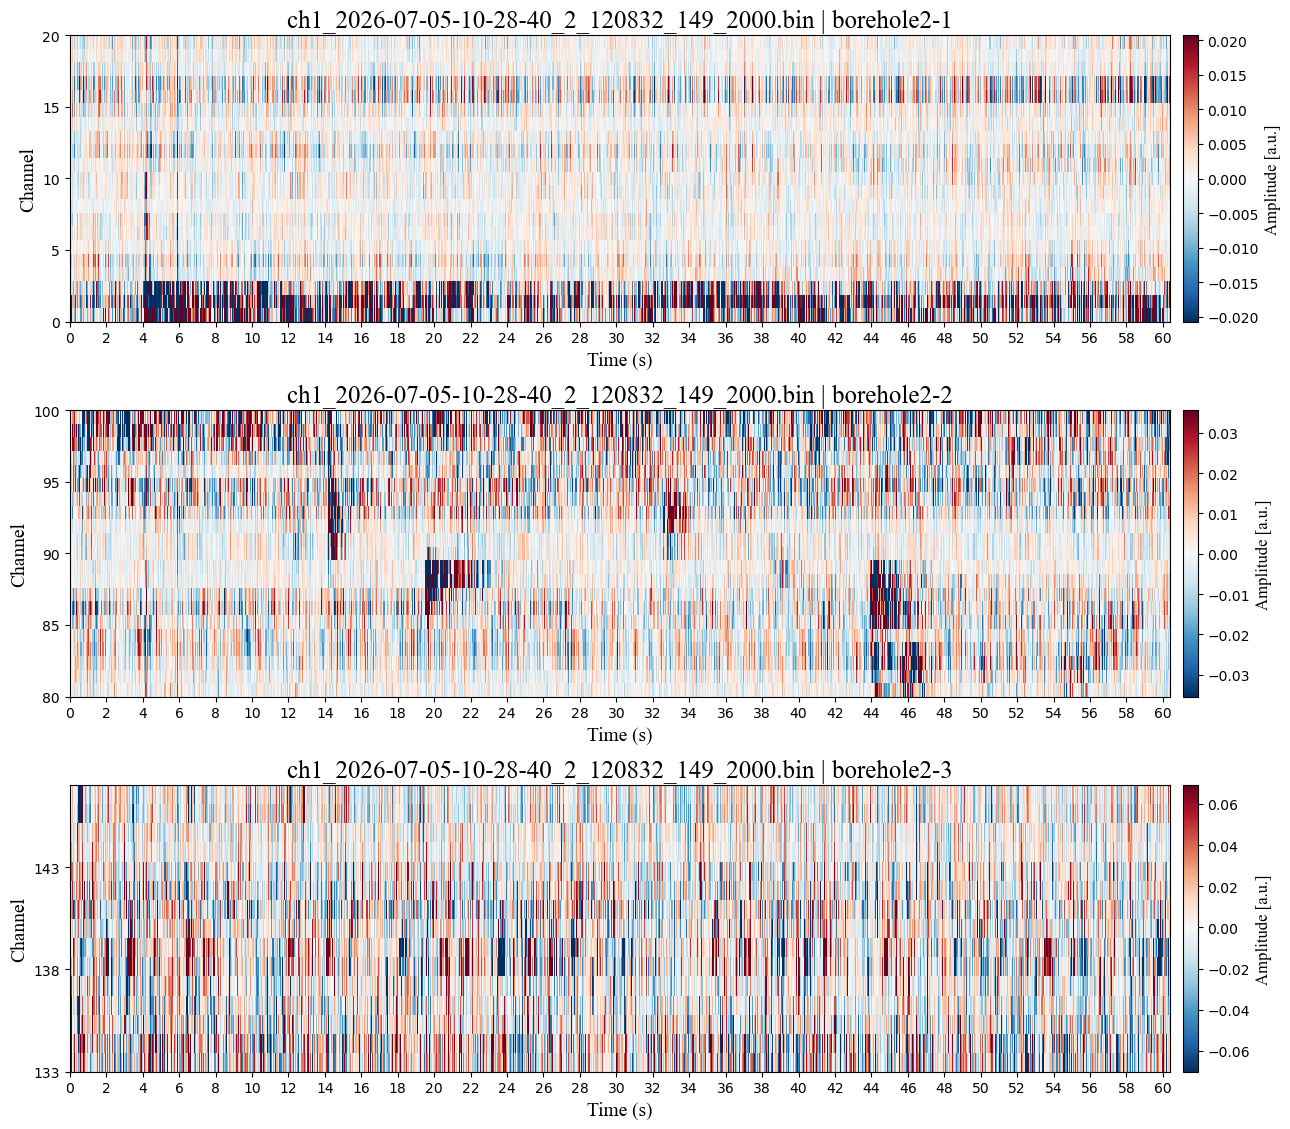

In [ ]:
# === 选择特定通道区段绘制瀑布图 ===
# channel_groups = [(120, 149)]  # 选择通道

# === 绘制 3 组通道的瀑布图 ===
channel_groups = [
    (0, 20),
    (80, 100),
    (133, 147)
]

files = files_selected

for fname in files:
    print(f"\n=== 处理文件：{fname} ===")

    data, fs = read_one_bin(folder, fname)
    data_p = preprocess_data(
        data,
        fs=fs,
        channel_start=0,
        channel_end=data.shape[0] - 1,
        freqmin=5, freqmax=100, bandpass_corners=4,
        remove_trend=True,
        remove_mean=True,
        apply_common_mode=False,
        downsample_factor=1,
        zerophase=False
    )

    n_channels, n_frames = data_p.shape
    t_end = n_frames / fs

    n_groups = len(channel_groups)
    fig, axes = plt.subplots(n_groups, 1, figsize=(14, 4*n_groups), sharex=False)

    if n_groups == 1:
        axes = [axes]

    for idx, (ax, (ch_start, ch_end)) in enumerate(zip(axes, channel_groups), start=1):

        if ch_end >= n_channels:
            print(f"警告：文件 {fname} 通道数不足，跳过 ({ch_start}-{ch_end})")
            continue

        sub_data = data_p[ch_start:ch_end+1, :]

        vmin = np.percentile(sub_data, 2)
        vmax = np.percentile(sub_data, 98)

        im = ax.imshow(
            sub_data,
            aspect='auto',
            cmap='RdBu_r',
            origin='lower',
            extent=[0, t_end, ch_start, ch_end],
            interpolation='nearest',
            vmin=vmin,
            vmax=vmax,
        )

        # === 子图独立标题 ===
        ax.set_title(f"{fname} | borehole2-{idx}", fontsize=18, fontname='Times New Roman')

        # === X 轴：每个子图都显示时间 ===
        ax.set_xlabel("Time (s)", fontsize=14, fontname='Times New Roman')
        ax.set_xticks(np.linspace(0, t_end, 6))
        ax.set_xticks(np.arange(0, int(t_end) + 1, step=2))   #时间刻度强制显示整数，间隔2s
                
        # === Y 轴：只显示整数通道编号 ===
        ax.set_ylabel("Channel", fontsize=14, fontname='Times New Roman')
        ax.set_yticks(np.arange(ch_start, ch_end+1, 5))  # 每 5 通道一刻度，可调整
        
        # === 每个子图独立 colorbar ===
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01)
        cbar.set_label("Amplitude [a.u.]", fontsize=12, fontname='Times New Roman')

        # ax.set_xlim(17, 19)

    # fig.suptitle(fname, fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  

    plt.show()

单道时频分析

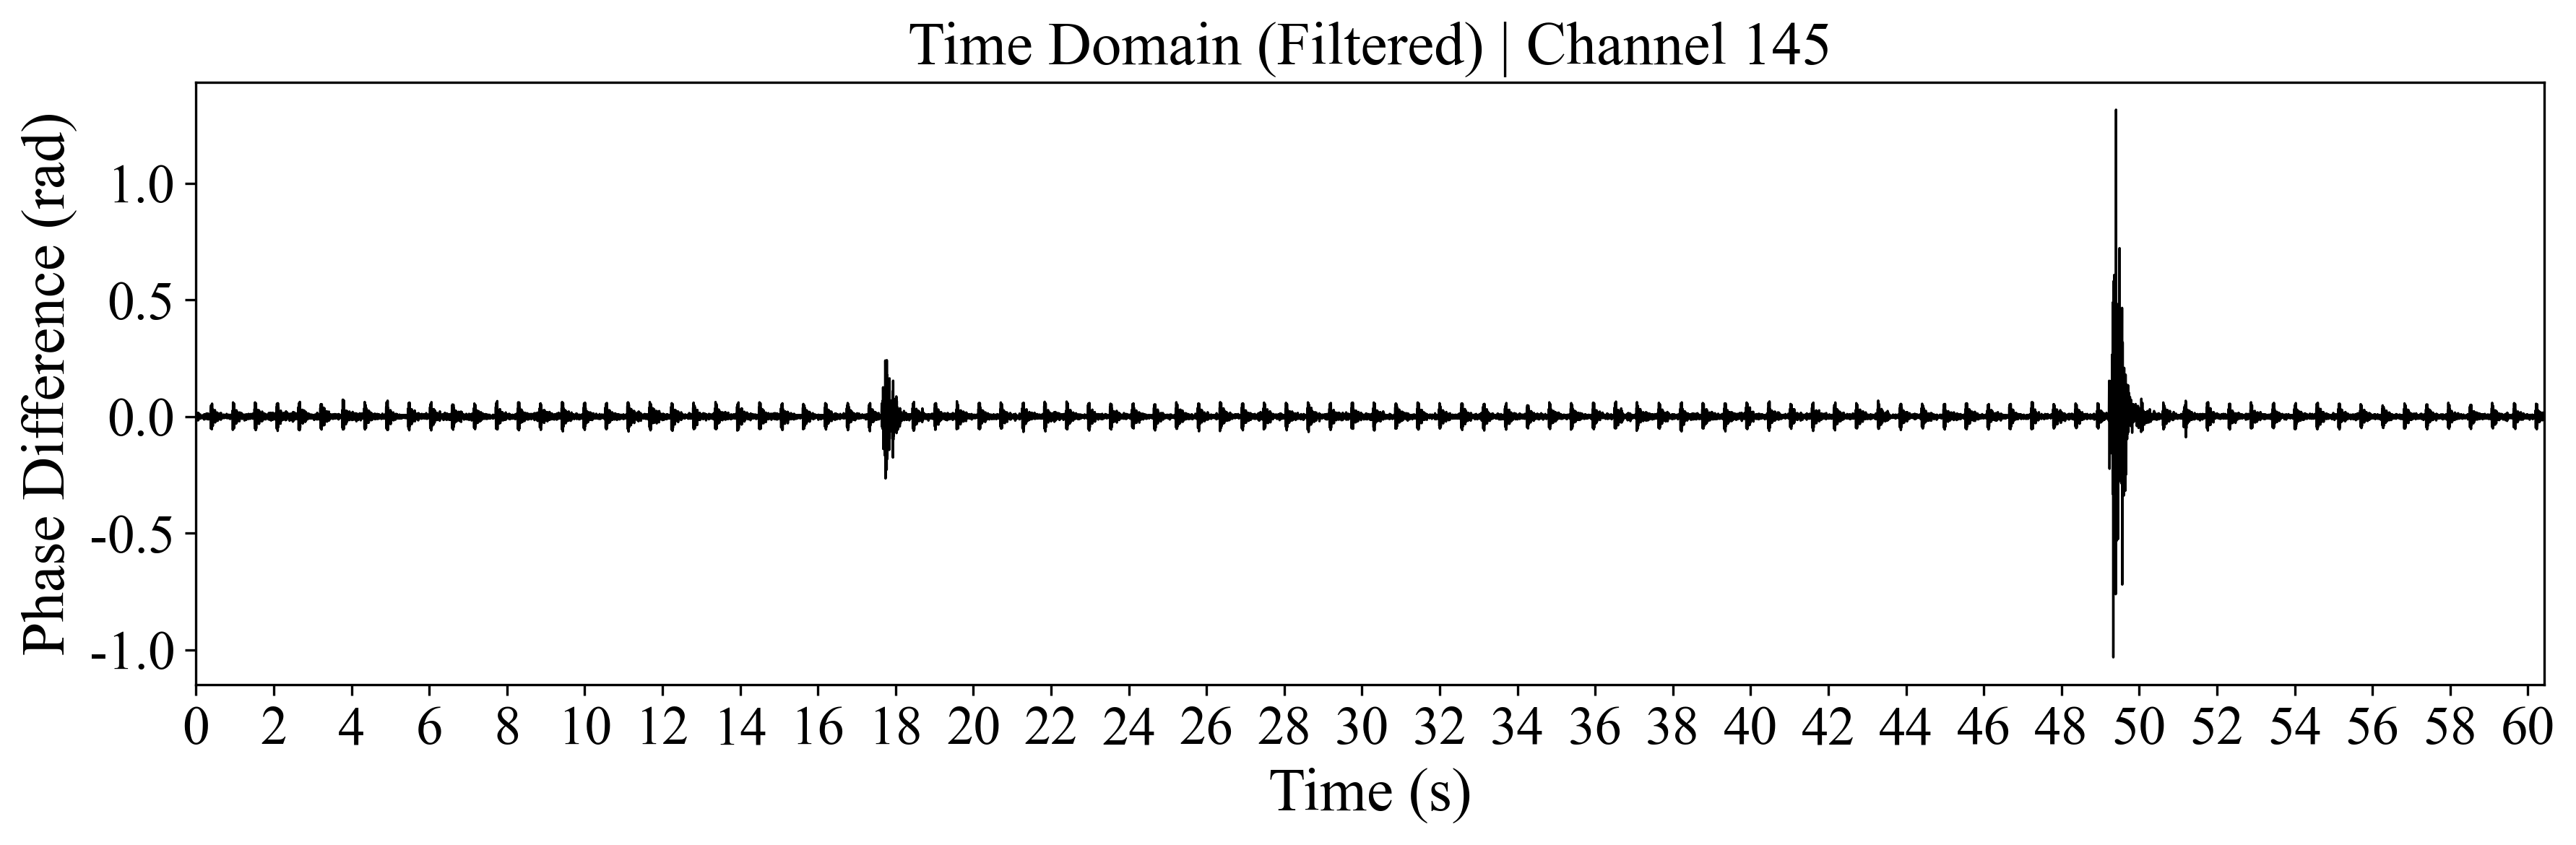

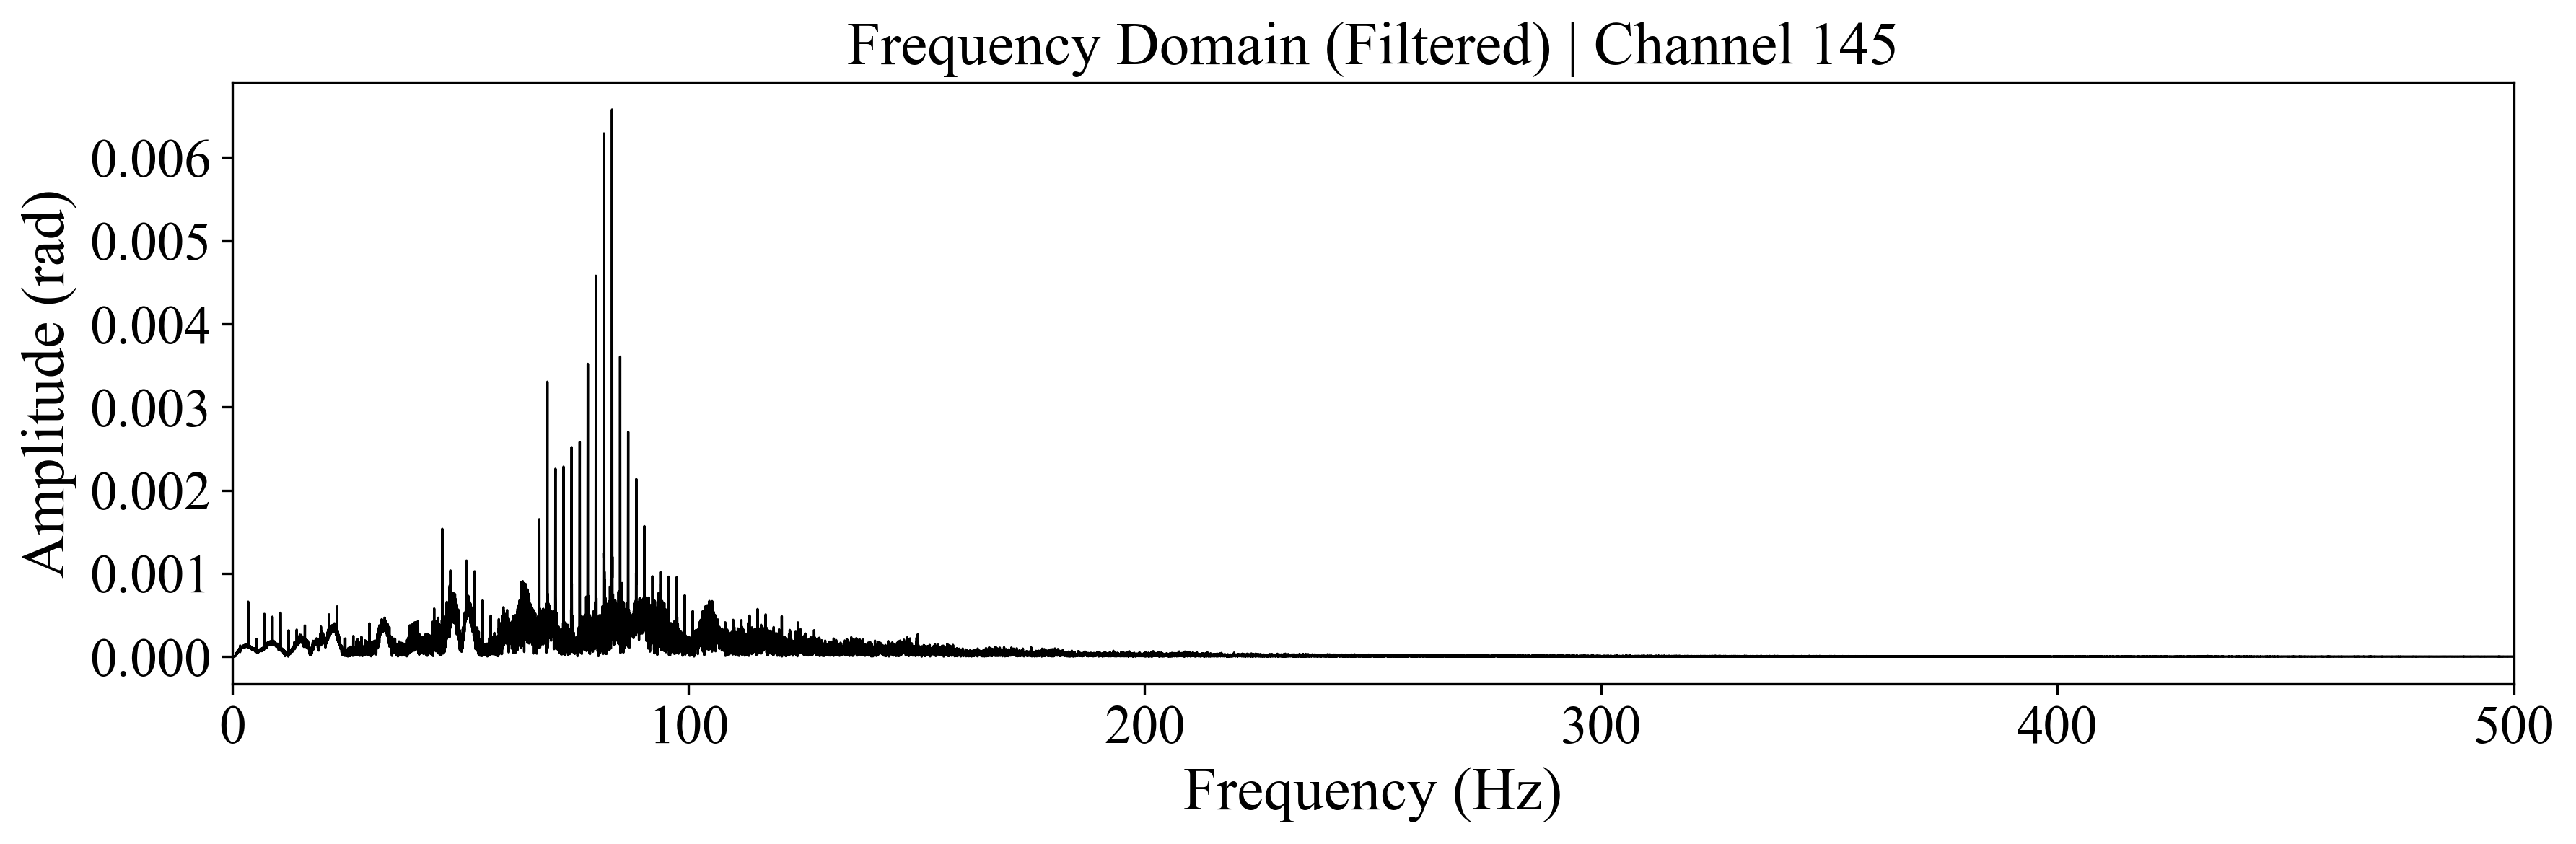

In [ ]:
# ================== 将选中的文件读入并拼接（带滤波） ==================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.unicode_minus'] = False

# ---- 检查 ----
if len(files_selected) == 0:
    raise RuntimeError("files_selected 为空")

# ---- 读取 + 滤波 + 拼接 ----
data_chunks = []
fs_list = []

for fname in files_selected:
    d, fs_file = read_one_bin(folder, fname)

    # ✅ 滤波（关键）
    d_p = preprocess_data(
        d,
        fs=fs_file,
        channel_start=0,
        channel_end=d.shape[0] - 1,
        # freqmin=5, freqmax=50, bandpass_corners=4,
        remove_trend=True,
        remove_mean=True,
        apply_common_mode=False,
        downsample_factor=1,
        zerophase=False
    )

    data_chunks.append(d_p)
    fs_list.append(fs_file)

fs = float(fs_list[0])

data_ = np.concatenate(data_chunks, axis=1)

# ================== 单通道 ==================
channel_id = 145

phi = data_[channel_id, :]

# ================== 时间轴 ==================
t = np.arange(phi.size) / fs

# ================== 频域 ==================
win = windows.hann(phi.size)
phi_win = phi * win

nfft = phi_win.size
fft_val = np.fft.rfft(phi_win)
freq = np.fft.rfftfreq(nfft, d=1/fs)

amp = np.abs(fft_val) / (np.sum(win) / 2)

# ================== 时域 ==================
fig_t, ax_t = plt.subplots(figsize=(12, 4))

ax_t.plot(t, phi, color='black', linewidth=0.8)
ax_t.set_title(f"Time Domain (Filtered) | Channel {channel_id}", fontsize=20)
ax_t.set_xlabel("Time (s)", fontsize=20)
ax_t.set_ylabel("Phase Difference (rad)", fontsize=20)

ax_t.set_xlim(t[0], t[-1])
ax_t.set_xticks(np.arange(0, int(t[-1]) + 1, step=2))

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

# ================== 频域 ==================
fig_f, ax_f = plt.subplots(figsize=(12, 4))

ax_f.plot(freq, amp, color='black', linewidth=0.8)
ax_f.set_title(f"Frequency Domain (Filtered) | Channel {channel_id}", fontsize=20)
ax_f.set_xlabel("Frequency (Hz)", fontsize=20)
ax_f.set_ylabel("Amplitude (rad)", fontsize=20)

ax_f.set_xlim(0, 500)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()